# RAFT-Stereo: Cost Volume Demonstration
This notebook demonstrates how a 3D cost volume is built using Sum of Absolute Differences (SAD).

In [1]:

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

def build_cost_volume_sad(left_img, right_img, max_disparity=192):
    """
    Builds a 3D cost volume using Sum of Absolute Differences (SAD).
    This is the simplest form of a cost volume. 
    Deep learning models use dot-products of features instead, but the shape is the same.
    
    Shape of output: (Max_Disparity, Height, Width)
    """
    B, C, H, W = left_img.shape
    
    # Initialize the 3D cost volume with zeros
    cost_volume = torch.zeros((B, max_disparity, H, W))
    
    for d in range(max_disparity):
        if d == 0:
            # When disparity is 0, left and right compare exactly at the same pixels
            cost_volume[:, d, :, :] = torch.sum(torch.abs(left_img - right_img), dim=1)
        else:
            # Shift the right image to the right by d pixels to simulate looking d pixels to the left
            shifted_right = torch.zeros_like(right_img)
            shifted_right[:, :, :, d:] = right_img[:, :, :, :-d]
            
            # Compute Absolute Difference
            diff = torch.sum(torch.abs(left_img - shifted_right), dim=1)
            cost_volume[:, d, :, :] = diff
            
    return cost_volume


In [2]:

# 1. Load the images
left_path = "/media/abrar/AbrarSSD/Datasets/stereo_samples_20260425_104147/left/00844.png"
right_path = "/media/abrar/AbrarSSD/Datasets/stereo_samples_20260425_104147/right/00844.png"

left_pil = Image.open(left_path).convert("RGB")
right_pil = Image.open(right_path).convert("RGB")

# Convert to PyTorch tensors (Shape: 1, 3, H, W)
left_tensor = torch.from_numpy(np.array(left_pil)).permute(2, 0, 1).unsqueeze(0).float() / 255.0
right_tensor = torch.from_numpy(np.array(right_pil)).permute(2, 0, 1).unsqueeze(0).float() / 255.0

print(f"Images loaded. Shape: {left_tensor.shape}")


Images loaded. Shape: torch.Size([1, 3, 720, 1280])


In [3]:

# 2. Build the Cost Volume
max_d = 128
print(f"Building 3D Cost Volume with max_disparity={max_d}...")
cv = build_cost_volume_sad(left_tensor, right_tensor, max_disparity=max_d)
print(f"Cost Volume built! Shape: {cv.shape} -> (Batch, Disparity, Height, Width)")


Building 3D Cost Volume with max_disparity=128...
Cost Volume built! Shape: torch.Size([1, 128, 720, 1280]) -> (Batch, Disparity, Height, Width)


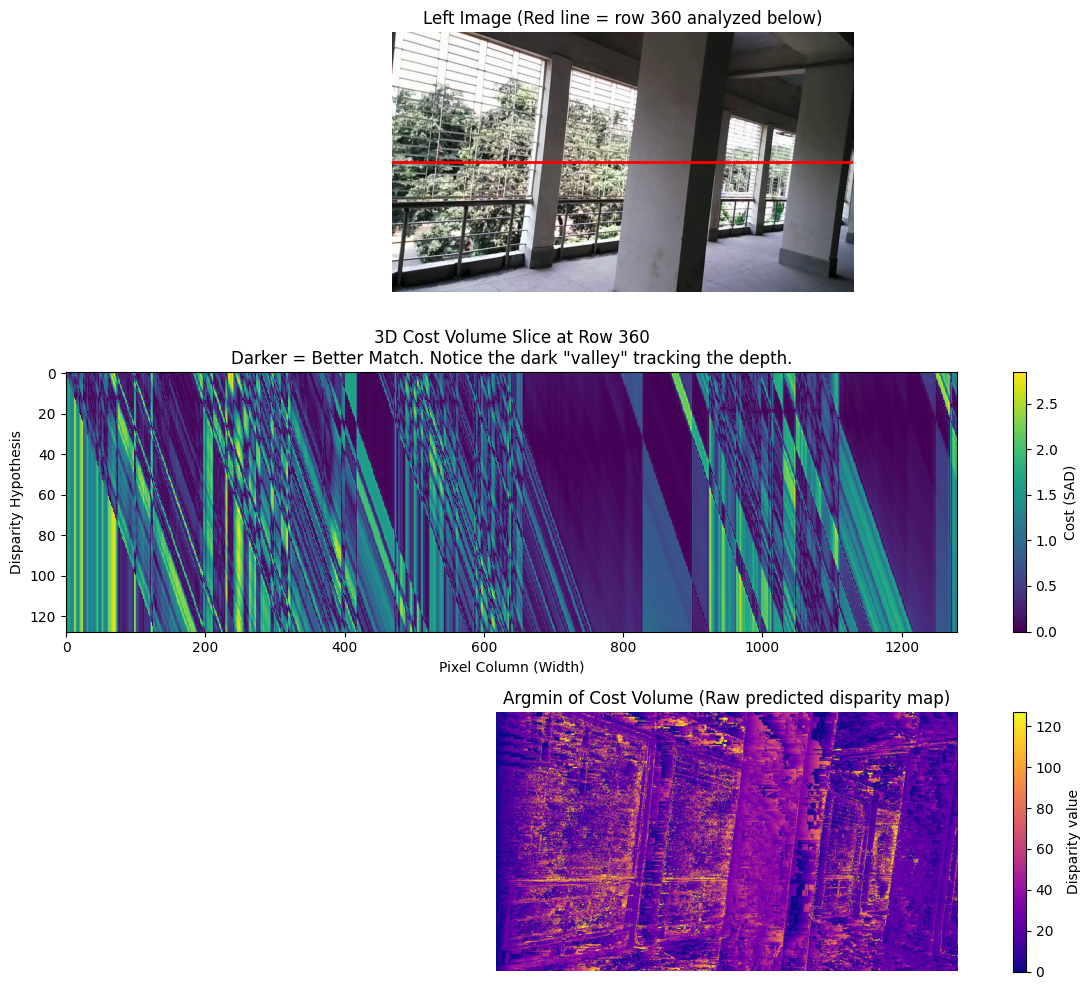

In [4]:

# 3. Visualize what the cost volume looks like
y_slice = left_tensor.shape[2] // 2  # Middle of the image

# Get the 2D slice: (Disparity, Width)
cv_slice = cv[0, :, y_slice, :].numpy()

# Also get the argmin (the predicted disparity)
predicted_disparity = torch.argmin(cv[0], dim=0).numpy()

# 4. Plotting
fig, axs = plt.subplots(3, 1, figsize=(12, 10))

axs[0].imshow(np.array(left_pil))
axs[0].axhline(y=y_slice, color="r", linestyle="-", linewidth=2)
axs[0].set_title(f"Left Image (Red line = row {y_slice} analyzed below)")
axs[0].axis("off")

im = axs[1].imshow(cv_slice, cmap="viridis", aspect="auto", interpolation="nearest")
axs[1].set_title(f"3D Cost Volume Slice at Row {y_slice}\nDarker = Better Match. Notice the dark \"valley\" tracking the depth.")
axs[1].set_ylabel("Disparity Hypothesis")
axs[1].set_xlabel("Pixel Column (Width)")
plt.colorbar(im, ax=axs[1], label="Cost (SAD)")

im2 = axs[2].imshow(predicted_disparity, cmap="plasma")
axs[2].set_title("Argmin of Cost Volume (Raw predicted disparity map)")
axs[2].axis("off")
plt.colorbar(im2, ax=axs[2], label="Disparity value")

plt.tight_layout()
plt.show()


In [ ]:
image = torch.zeros(5, 6) # 5 rows, 6 columns 
image.shape, image

(torch.Size([5, 6]),
 tensor([[0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0.]]))

In [16]:

image = torch.zeros(5, 6, 1) # 5 rows, 6 columns, 1 member per element
image.shape

#  tensor([
    #       [[0.], [0.], [0.], [0.], [0.], [0.]],
    #       [[0.], [0.], [0.], [0.], [0.], [0.]],
    #       [[0.], [0.], [0.], [0.], [0.], [0.]],
    #       [[0.], [0.], [0.], [0.], [0.], [0.]],
    #       [[0.], [0.], [0.], [0.], [0.], [0.]]
    # ]))

torch.Size([5, 6, 1])

In [17]:
image = torch.zeros(5, 6, 3) # 5 rows, 6 columns, 3 member(channels) per element
image.shape

torch.Size([5, 6, 3])

In [ ]:
image_unsqueezed = image.unsqueeze(0)
image_unsqueezed.shape # torch.Size([1, 5, 6, 3])

torch.Size([1, 5, 6, 3])

In [ ]:
image_unsqueezed = image.unsqueeze(1)
image_unsqueezed.shape # torch.Size([5, 1, 6, 3])

torch.Size([5, 1, 6, 3])

In [21]:
image_unsqueezed = image.unsqueeze(2)
image_unsqueezed.shape # torch.Size([5, 6, 1, 3])

torch.Size([5, 6, 1, 3])